In [9]:
import fastf1
import pandas as pd

# Réglages d'affichage
fastf1.set_log_level('ERROR')             # masque les messages INFO / WARNING de FastF1
pd.set_option('display.max_rows', None)   # affiche toutes les lignes d'un tableau (pas de "...")

# Colonnes à mettre en forme pour l'affichage
INT_COLS = ['LapNumber', 'TyreLife', 'Stint']                        # nombres entiers stockés en décimaux
TIME_COLS = ['LapTime', 'LapTimeFuelCorrected',
             'PitInTime', 'PitOutTime', 'PitDuration']               # durées (Timedelta)

# Signification des codes TrackStatus (un caractère = un statut)
TRACK_STATUS_LABELS = {
    '1': 'Track clear',
    '2': 'Yellow flag',
    '4': 'Safety Car',
    '5': 'Red flag',
    '6': 'VSC deployed',
    '7': 'VSC ending',
}

# Style du meilleur tour (violet, comme sur les écrans de chronométrage F1)
BEST_LAP_STYLE = {'background-color': '#9b30d9', 'color': 'white', 'font-weight': 'bold'}


def format_time(td):
    """Convertit une durée en texte m:ss.mmm (ou h:mm:ss.mmm au-delà d'une heure)."""
    if pd.isna(td):
        return ''
    total_ms = round(td.total_seconds() * 1000)
    hours, rest = divmod(total_ms, 3_600_000)
    minutes, rest = divmod(rest, 60_000)
    seconds, ms = divmod(rest, 1000)
    if hours:
        return f'{hours}:{minutes:02d}:{seconds:02d}.{ms:03d}'
    return f'{minutes}:{seconds:02d}.{ms:03d}'


def format_track_status(code):
    """Traduit un code TrackStatus en texte ('24' -> 'Yellow flag + Safety Car')."""
    return ' + '.join(TRACK_STATUS_LABELS.get(c, c) for c in str(code))


def pretty(df):
    """Renvoie une copie du tableau mise en forme pour la lecture (ne pas l'utiliser pour calculer)."""
    view = df.copy()
    for col in INT_COLS:
        if col in view.columns:
            view[col] = view[col].astype('Int64')
    for col in TIME_COLS:
        if col in view.columns:
            view[col] = view[col].map(format_time)
    if 'TrackStatus' in view.columns:
        view['TrackStatus'] = view['TrackStatus'].map(format_track_status)
    return view


def show_laps(df):
    """Affiche le tableau mis en forme, avec le meilleur tour du tableau en violet."""
    best_lap_index = df['LapTime'].idxmin()   # numéro de ligne du chrono le plus petit
    best_lap_cell = pd.IndexSlice[[best_lap_index], ['LapTime']]
    return pretty(df).style.set_properties(subset=best_lap_cell, **BEST_LAP_STYLE)


fastf1.Cache.enable_cache('../data/cache')

session = fastf1.get_session(2024, 'Spain', 'R')   # R = course
session.load()

laps = session.laps
print(laps.shape)
print(laps.columns.tolist())

# Temps passé dans la voie des stands = sortie (tour suivant) - entrée (tour courant).
# PitOutTime est sur la ligne du tour de sortie : on le remonte d'une ligne, pilote par pilote.
next_pit_out = laps.groupby('Driver')['PitOutTime'].shift(-1)
laps['PitDuration'] = next_pit_out - laps['PitInTime']

# On ne garde que les tours de Norris (masque booléen sur la colonne Driver)
driver_laps = laps[laps['Driver'] == 'HAM']

(1310, 31)
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [10]:
# --- Correction de l'effet carburant ---
# La voiture s'allège à chaque tour et gagne du temps sans que les pneus y soient pour rien.
# On ramène tous les chronos au poids du départ pour isoler l'usure des pneus.

FUEL_START_KG = 110        # carburant embarqué au départ (kg) : maximum autorisé en course
FUEL_TIME_PER_KG = 0.03    # temps perdu au tour par kg embarqué (s/kg) : valeur générique, non mesurée ici

# Gain de temps par tour dû à l'allègement (s/tour), en supposant une consommation régulière
fuel_effect_per_lap = FUEL_START_KG / session.total_laps * FUEL_TIME_PER_KG
print(f'Effet carburant : {fuel_effect_per_lap:.3f} s/tour')

# Chrono corrigé = chrono mesuré + temps gagné depuis le départ grâce à l'allègement
fuel_gain = pd.to_timedelta(fuel_effect_per_lap * (laps['LapNumber'] - 1), unit='s')
laps['LapTimeFuelCorrected'] = laps['LapTime'] + fuel_gain

# Mêmes tours que dans la cellule précédente, avec la nouvelle colonne
driver_laps = laps.loc[driver_laps.index]
show_laps(driver_laps[['Driver', 'LapNumber', 'LapTime', 'LapTimeFuelCorrected', 'Compound',
                       'TyreLife', 'Stint', 'PitDuration', 'TrackStatus']])

Effet carburant : 0.050 s/tour


,Driver,LapNumber,LapTime,LapTimeFuelCorrected,Compound,TyreLife,Stint,PitDuration,TrackStatus
132,HAM,1,1:24.441,1:24.441,SOFT,4,1,,Track clear
133,HAM,2,1:20.594,1:20.644,SOFT,5,1,,Track clear
134,HAM,3,1:20.421,1:20.521,SOFT,6,1,,Track clear
135,HAM,4,1:20.496,1:20.646,SOFT,7,1,,Track clear
136,HAM,5,1:21.050,1:21.250,SOFT,8,1,,Track clear
137,HAM,6,1:21.200,1:21.450,SOFT,9,1,,Track clear
138,HAM,7,1:21.223,1:21.523,SOFT,10,1,,Track clear
139,HAM,8,1:21.538,1:21.888,SOFT,11,1,,Track clear
140,HAM,9,1:21.207,1:21.607,SOFT,12,1,,Track clear
141,HAM,10,1:21.380,1:21.830,SOFT,13,1,,Track clear


In [11]:
# --- Nettoyage : on ne garde que les tours qui reflètent le rythme normal en piste ---
OUTLIER_RATIO = 1.03     # tour anormal : plus de 3 % plus lent que le rythme médian du relais
TRAFFIC_GAP_S = 1.0      # trafic : moins de 1,0 s derrière la voiture qui précède sur la piste

# Chaque règle est un masque booléen : True = tour à écarter.
is_first_lap = laps['LapNumber'] == 1      # départ arrêté, peloton groupé
is_in_lap = laps['PitInTime'].notna()      # tour d'entrée au stand (ralentissement)
is_out_lap = laps['PitOutTime'].notna()    # tour de sortie du stand (traversée de la voie des stands)
is_start_or_pit = is_first_lap | is_in_lap | is_out_lap    # | = "ou"

# Trafic : écart (s) à la voiture qui a franchi la ligne juste avant, quel que soit son tour.
# On trie tous les passages sur la ligne par instant, puis on prend la différence entre lignes voisines.
laps['GapAhead'] = laps.sort_values('Time')['Time'].diff().dt.total_seconds()
is_in_traffic = laps['GapAhead'] < TRAFFIC_GAP_S

# Tour anormal : comparé au chrono médian de son relais (même pilote, même relais),
# calculé sans les tours de départ et de stand (qui n'ont donc pas de médiane : la comparaison donne False)
lap_seconds = laps['LapTime'].dt.total_seconds()
stint_median = lap_seconds[~is_start_or_pit].groupby([laps['Driver'], laps['Stint']]).transform('median')
is_outlier = lap_seconds > OUTLIER_RATIO * stint_median.reindex(laps.index)

# Tableau des tours exploitables ( ~ = "non" ). laps reste complet.
clean_laps = laps[~(is_start_or_pit | is_outlier | is_in_traffic)]

print(f'Tours au départ         : {len(laps)}')
print(f'  premier tour          : {is_first_lap.sum()}')
print(f"  tours d'entrée        : {is_in_lap.sum()}")
print(f'  tours de sortie       : {is_out_lap.sum()}')
print(f'  tours anormaux        : {(is_outlier & ~is_start_or_pit).sum()}')
print(f'  tours dans le trafic  : {(is_in_traffic & ~is_start_or_pit).sum()}')
print(f'Tours conservés         : {len(clean_laps)}')

# Nombre de tours par composé, avant et après nettoyage
pd.DataFrame({'Avant': laps['Compound'].value_counts(),
              'Après': clean_laps['Compound'].value_counts()})

Tours au départ         : 1310
  premier tour          : 20
  tours d'entrée        : 42
  tours de sortie       : 43
  tours anormaux        : 14
  tours dans le trafic  : 201
Tours conservés         : 992


,Avant,Après
Compound,,
HARD,360,308
MEDIUM,439,357
SOFT,511,327


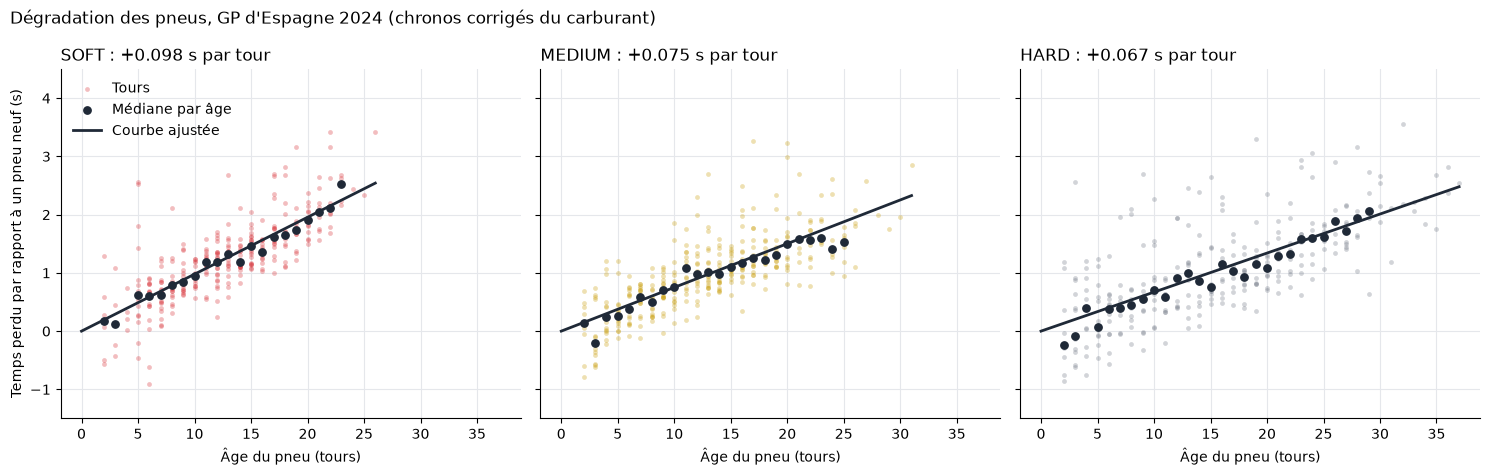

,Tours,Usure (s/tour),Écart type degré 1 (s),Écart type degré 2 (s),Écart type degré 3 (s)
Composé,,,,,
SOFT,327,0.098,0.419,0.417,0.415
MEDIUM,357,0.075,0.424,0.417,0.416
HARD,308,0.067,0.582,0.582,0.581


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Dégradation des pneus par composé ---
DEGRADATION_DEGREE = 1                      # degré du polynôme d'usure (1 = droite)
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
COMPOUND_COLORS = {'SOFT': '#d6262d', 'MEDIUM': '#c79a00', 'HARD': '#6b7280'}   # couleurs usuelles Pirelli
MIN_LAPS_PER_AGE = 5                        # nb de tours minimum pour afficher la médiane d'un âge de pneu


def fit_degradation(compound_laps, degree):
    """Ajuste, pour un composé, un niveau de rythme propre à chaque relais et une courbe d'usure commune.

    Renvoie les coefficients du polynôme (s/tour, s/tour², ...), le temps perdu par rapport
    à un pneu neuf pour chaque tour (s), et l'écart type entre les tours et la courbe (s).
    """
    stint = [compound_laps['Driver'], compound_laps['Stint']]
    lap_seconds = compound_laps['LapTimeFuelCorrected'].dt.total_seconds()
    # Une colonne par puissance de l'âge du pneu : âge, âge², ...
    age_powers = pd.DataFrame({k: compound_laps['TyreLife'] ** k for k in range(1, degree + 1)})

    # On retire à chaque relais sa propre moyenne : il ne reste que les variations à l'intérieur
    # du relais, ce qui rend comparables des voitures de rythmes différents.
    seconds_centered = lap_seconds - lap_seconds.groupby(stint).transform('mean')
    powers_centered = age_powers - age_powers.groupby(stint).transform('mean')
    coefs, *_ = np.linalg.lstsq(powers_centered.to_numpy(float), seconds_centered.to_numpy(float), rcond=None)

    wear = age_powers.to_numpy(float) @ coefs                           # usure prédite pour chaque tour
    new_tyre_pace = (lap_seconds - wear).groupby(stint).transform('mean')   # rythme du relais en pneu neuf
    time_lost = lap_seconds - new_tyre_pace
    residual_std = np.sqrt(((time_lost - wear) ** 2).mean())
    return coefs, time_lost, residual_std


degradation_coefs = {}    # composé -> coefficients du polynôme d'usure, réutilisés par le simulateur
summary = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, compound in zip(axes, COMPOUNDS):
    compound_laps = clean_laps[clean_laps['Compound'] == compound]
    coefs, time_lost, residual_std = fit_degradation(compound_laps, DEGRADATION_DEGREE)
    degradation_coefs[compound] = coefs

    # Nuage des tours, médiane par âge de pneu, et courbe ajustée
    ax.scatter(compound_laps['TyreLife'], time_lost, s=12, alpha=0.3, linewidths=0,
               color=COMPOUND_COLORS[compound], label='Tours')
    by_age = time_lost.groupby(compound_laps['TyreLife']).agg(['median', 'size'])
    by_age = by_age[by_age['size'] >= MIN_LAPS_PER_AGE]
    ax.scatter(by_age.index, by_age['median'], s=28, color='#1f2937', zorder=3, label='Médiane par âge')
    ages = np.arange(0, compound_laps['TyreLife'].max() + 1)
    ax.plot(ages, np.polyval([*coefs[::-1], 0], ages), color='#1f2937', linewidth=2, label='Courbe ajustée')

    ax.set_title(f'{compound} : {coefs[0]:+.3f} s par tour', loc='left')
    ax.set_xlabel('Âge du pneu (tours)')
    ax.grid(color='#e5e7eb', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    # Écart type obtenu avec d'autres degrés, pour comparer
    row = {'Composé': compound, 'Tours': len(compound_laps), 'Usure (s/tour)': round(coefs[0], 3)}
    for degree in (1, 2, 3):
        row[f'Écart type degré {degree} (s)'] = round(fit_degradation(compound_laps, degree)[2], 3)
    summary.append(row)

axes[0].set_ylabel('Temps perdu par rapport à un pneu neuf (s)')
axes[0].set_ylim(-1.5, 4.5)
axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('Dégradation des pneus, GP d\'Espagne 2024 (chronos corrigés du carburant)', x=0.01, ha='left')
fig.tight_layout()
fig.savefig('../figures/degradation_by_compound.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame(summary).set_index('Composé')

In [13]:
# --- Modèle complet du temps au tour ---
# chrono = rythme du pilote + écart du composé à neuf + effet du numéro de tour + usure × âge du pneu
# Tout est estimé en une seule régression sur les chronos bruts : l'effet du numéro de tour
# (carburant + amélioration de la piste) n'est donc plus supposé, il est mesuré.
REFERENCE_COMPOUND = 'SOFT'    # composé de référence : son écart à neuf vaut 0 par définition

lap_seconds = clean_laps['LapTime'].dt.total_seconds()
tyre_age = clean_laps['TyreLife'].astype(float)

# Colonnes explicatives. get_dummies crée une colonne de 0/1 par valeur (une par pilote, une par composé).
driver_cols = pd.get_dummies(clean_laps['Driver']).astype(float)
compound_cols = pd.get_dummies(clean_laps['Compound']).astype(float)[COMPOUNDS]
offset_cols = compound_cols.drop(columns=REFERENCE_COMPOUND).add_prefix('offset_')
wear_cols = compound_cols.mul(tyre_age, axis=0).add_prefix('wear_')    # âge du pneu, séparé par composé
lap_col = clean_laps[['LapNumber']].astype(float)
features = pd.concat([driver_cols, offset_cols, lap_col, wear_cols], axis=1)

# Moindres carrés : les coefficients qui collent le mieux aux chronos
x = features.to_numpy()
values, *_ = np.linalg.lstsq(x, lap_seconds.to_numpy(), rcond=None)
coefs = pd.Series(values, index=features.columns)
residuals = lap_seconds - x @ values
residual_std = np.sqrt((residuals ** 2).sum() / (len(x) - x.shape[1]))
# Incertitude (erreur type) de chaque coefficient
coef_errors = pd.Series(residual_std * np.sqrt(np.diag(np.linalg.inv(x.T @ x))), index=features.columns)

# Paramètres du modèle, réutilisés par le simulateur
pace_model = {
    'driver_pace': coefs[driver_cols.columns],     # chrono théorique de chaque pilote : tour 0, Soft neuf (s)
    'lap_effect': coefs['LapNumber'],              # gain par tour de course (s/tour, négatif)
    'compound_offset': {c: coefs.get(f'offset_{c}', 0.0) for c in COMPOUNDS},    # écart à neuf vs Soft (s)
    'wear_per_lap': {c: coefs[f'wear_{c}'] for c in COMPOUNDS},                  # usure (s/tour d'âge)
    'residual_std': residual_std,                  # dispersion d'un tour autour du modèle (s)
}

print(f"Effet du numéro de tour : {pace_model['lap_effect']:+.3f} s/tour "
      f"(hypothèse carburant seule : {-fuel_effect_per_lap:+.3f})")
print(f"Dispersion d'un tour autour du modèle : {residual_std:.2f} s")

pd.DataFrame({
    'Écart à neuf vs Soft (s)': [pace_model['compound_offset'][c] for c in COMPOUNDS],
    '± écart': [coef_errors.get(f'offset_{c}', 0.0) for c in COMPOUNDS],
    'Usure (s/tour)': [pace_model['wear_per_lap'][c] for c in COMPOUNDS],
    '± usure': [coef_errors[f'wear_{c}'] for c in COMPOUNDS],
}, index=COMPOUNDS).round(3)

Effet du numéro de tour : -0.058 s/tour (hypothèse carburant seule : -0.050)
Dispersion d'un tour autour du modèle : 0.51 s


,Écart à neuf vs Soft (s),± écart,Usure (s/tour),± usure
SOFT,0.000,0.000,0.101,0.006
MEDIUM,0.229,0.095,0.083,0.004
HARD,0.377,0.103,0.076,0.004


In [14]:
# --- Temps perdu au départ et à chaque arrêt ---
def tyre_seconds(compound, tyre_age):
    """Temps perdu au tour à cause du pneu, par rapport à un Soft neuf (s)."""
    return pace_model['compound_offset'][compound] + pace_model['wear_per_lap'][compound] * tyre_age


def base_seconds(driver, lap_number):
    """Chrono du pilote en Soft neuf à ce tour de course (s), sans l'effet du pneu."""
    return pace_model['driver_pace'][driver] + pace_model['lap_effect'] * lap_number


# Chrono prédit par le modèle pour chaque tour réel, puis écart entre le réel et la prédiction
predicted_seconds = pd.Series(
    [base_seconds(d, n) + tyre_seconds(c, a)
     for d, n, c, a in zip(laps['Driver'], laps['LapNumber'], laps['Compound'], laps['TyreLife'])],
    index=laps.index)
extra_seconds = laps['LapTime'].dt.total_seconds() - predicted_seconds

# Le surcoût typique (médiane) de chaque type de tour particulier devient un paramètre du simulateur
pace_model['start_loss'] = extra_seconds[is_first_lap].median()                    # départ arrêté
pace_model['pit_in_loss'] = extra_seconds[is_in_lap].median()                      # tour d'entrée au stand
pace_model['pit_out_loss'] = extra_seconds[is_out_lap & ~is_first_lap].median()    # tour de sortie du stand
pit_loss = pace_model['pit_in_loss'] + pace_model['pit_out_loss']

print(f"Temps perdu au départ          : {pace_model['start_loss']:.1f} s")
print(f"Temps perdu au tour d'entrée   : {pace_model['pit_in_loss']:.1f} s")
print(f"Temps perdu au tour de sortie  : {pace_model['pit_out_loss']:.1f} s")
print(f'Coût total d\'un arrêt          : {pit_loss:.1f} s')

Temps perdu au départ          : 7.0 s
Temps perdu au tour d'entrée   : 3.8 s
Temps perdu au tour de sortie  : 19.0 s
Coût total d'un arrêt          : 22.7 s


In [15]:
from itertools import combinations, product

# --- Simulateur : temps de course d'une stratégie ---
TOTAL_LAPS = int(session.total_laps)
MAX_STOPS = 3                    # nombre maximal d'arrêts testés
MIN_COMPOUNDS = 2                # règlement : au moins deux composés différents en course
REFERENCE_DRIVER = 'VER'         # pilote simulé (le vainqueur) ; le classement des stratégies n'en dépend pas


def simulate_race(strategy, driver):
    """Chronos tour par tour (s) d'une stratégie, pneus neufs à chaque relais.

    strategy : liste de relais (composé, dernier tour du relais), ex. [('SOFT', 17), ('MEDIUM', 44), ('SOFT', 66)]
    """
    seconds = np.array([base_seconds(driver, n) for n in range(1, TOTAL_LAPS + 1)])
    first_lap = 1
    for compound, last_lap in strategy:
        for lap in range(first_lap, last_lap + 1):
            seconds[lap - 1] += tyre_seconds(compound, lap - first_lap + 1)    # âge 1 au premier tour du relais
        first_lap = last_lap + 1
    seconds[0] += pace_model['start_loss']
    for _, in_lap in strategy[:-1]:          # un arrêt à la fin de chaque relais, sauf le dernier
        seconds[in_lap - 1] += pace_model['pit_in_loss']
        seconds[in_lap] += pace_model['pit_out_loss']
    return seconds


# Pour tester vite des milliers de stratégies : coût pneu d'un relais de n tours, calculé une fois pour toutes
stint_cost = {c: np.concatenate([[0], np.cumsum([tyre_seconds(c, age) for age in range(1, TOTAL_LAPS + 1)])])
              for c in COMPOUNDS}
# Part du temps de course commune à toutes les stratégies (rythme du pilote, numéro de tour, départ)
common_seconds = sum(base_seconds(REFERENCE_DRIVER, n) for n in range(1, TOTAL_LAPS + 1)) + pace_model['start_loss']

rows = []
for n_stops in range(1, MAX_STOPS + 1):
    compound_choices = [c for c in product(COMPOUNDS, repeat=n_stops + 1) if len(set(c)) >= MIN_COMPOUNDS]
    for pit_laps in combinations(range(1, TOTAL_LAPS), n_stops):      # tours d'entrée au stand, croissants
        stint_lengths = np.diff([0, *pit_laps, TOTAL_LAPS])
        # Pour ces tours d'arrêt, on ne garde que le meilleur enchaînement de composés
        cost, compounds = min((sum(stint_cost[c][n] for c, n in zip(choice, stint_lengths)), choice)
                              for choice in compound_choices)
        rows.append({'Arrêts': n_stops, 'Tours d\'arrêt': pit_laps, 'Composés': compounds,
                     'Temps (s)': common_seconds + cost + n_stops * pit_loss})

strategies = pd.DataFrame(rows)
strategies['Écart (s)'] = strategies['Temps (s)'] - strategies['Temps (s)'].min()
print(f'{len(strategies)} combinaisons de tours d\'arrêt testées')

# Meilleure stratégie pour chaque nombre d'arrêts
best_by_stops = strategies.loc[strategies.groupby('Arrêts')['Temps (s)'].idxmin()].set_index('Arrêts')
best_by_stops['Temps'] = pd.to_timedelta(best_by_stops['Temps (s)'], unit='s').map(format_time)
best_by_stops[['Tours d\'arrêt', 'Composés', 'Temps', 'Écart (s)']].round(1)

45825 combinaisons de tours d'arrêt testées


,Tours d'arrêt,Composés,Temps,Écart (s)
Arrêts,,,,
1,"(32,)","(MEDIUM, HARD)",1:28:28.369,9.6
2,"(21, 43)","(SOFT, SOFT, MEDIUM)",1:28:18.790,0.0
3,"(16, 32, 49)","(SOFT, SOFT, SOFT, MEDIUM)",1:28:24.013,5.2


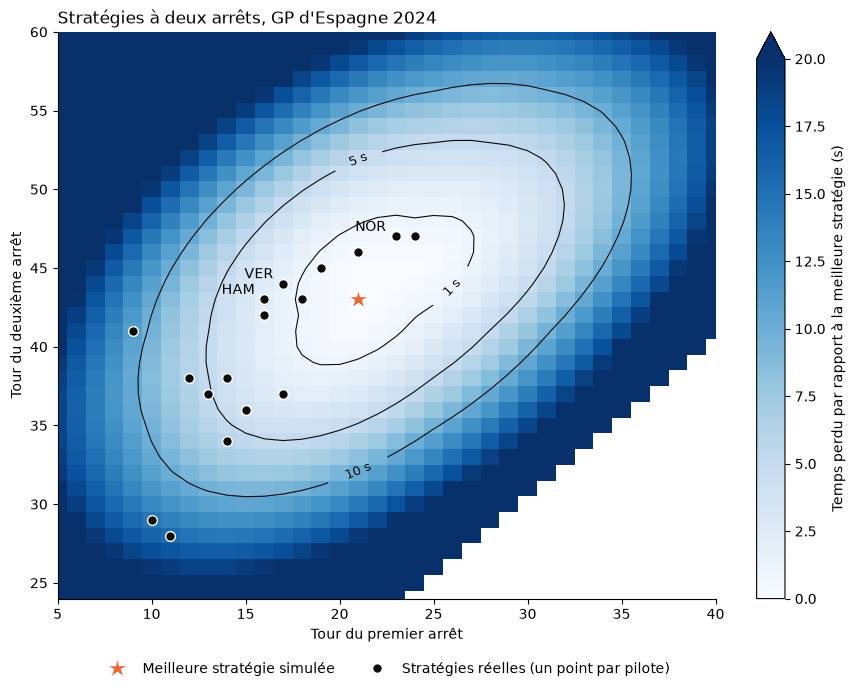

,Relais,Écart au meilleur (s)
Stratégie de,,
VER,SOFT → tour 17 / MEDIUM → tour 44 / SOFT → tou...,1.5
NOR,SOFT → tour 23 / MEDIUM → tour 47 / SOFT → tou...,0.4
HAM,SOFT → tour 16 / MEDIUM → tour 43 / SOFT → tou...,2.1


In [16]:
# --- Stratégie à deux arrêts : à quels tours s'arrêter ? ---
# Carte du temps perdu en fonction des deux tours d'arrêt (meilleurs composés pour chaque couple de tours)
MAX_GAP_SHOWN_S = 20             # au-delà, la couleur ne change plus
CONTOUR_LEVELS_S = [1, 5, 10]    # lignes de niveau : stratégies à moins de 1, 5 et 10 s de la meilleure
LABELLED_DRIVERS = list(session.results['Abbreviation'].head(3))    # pilotes nommés sur la carte : le podium

two_stops = strategies[strategies['Arrêts'] == 2].copy()
two_stops['Premier arrêt'] = two_stops['Tours d\'arrêt'].str[0]
two_stops['Deuxième arrêt'] = two_stops['Tours d\'arrêt'].str[1]
# Tableau à deux entrées : une ligne par tour du deuxième arrêt, une colonne par tour du premier
gap_grid = two_stops.pivot(index='Deuxième arrêt', columns='Premier arrêt', values='Écart (s)')

# Arrêts réels des pilotes qui ont fait exactement deux arrêts
real_stops = laps[is_in_lap].groupby('Driver')['LapNumber'].apply(list)
real_two_stops = real_stops[real_stops.str.len() == 2]

fig, ax = plt.subplots(figsize=(9, 7))
mesh = ax.pcolormesh(gap_grid.columns, gap_grid.index, gap_grid.to_numpy(), cmap='Blues',
                     vmin=0, vmax=MAX_GAP_SHOWN_S, shading='nearest')
contours = ax.contour(gap_grid.columns, gap_grid.index, gap_grid.to_numpy(), levels=CONTOUR_LEVELS_S,
                      colors='#0b0b0b', linewidths=0.8)
ax.clabel(contours, fmt='%d s', fontsize=9)
fig.colorbar(mesh, ax=ax, extend='max', label='Temps perdu par rapport à la meilleure stratégie (s)')

# Meilleure stratégie du simulateur et stratégies réelles
best_two_stops = two_stops.loc[two_stops['Écart (s)'].idxmin()]
ax.plot(best_two_stops['Premier arrêt'], best_two_stops['Deuxième arrêt'], linestyle='none', marker='*',
        markersize=16, color='#eb6834', markeredgecolor='white', label='Meilleure stratégie simulée')
ax.plot(real_two_stops.str[0], real_two_stops.str[1], linestyle='none', marker='o', markersize=7,
        color='#0b0b0b', markeredgecolor='white', label='Stratégies réelles (un point par pilote)')
for driver in LABELLED_DRIVERS:
    if driver in real_two_stops.index:
        ax.annotate(driver, real_two_stops[driver], xytext=(-7, 4), textcoords='offset points',
                    ha='right', fontsize=10)

ax.set_xlabel('Tour du premier arrêt')
ax.set_ylabel('Tour du deuxième arrêt')
ax.set_xlim(5, 40)
ax.set_ylim(24, 60)
ax.set_title('Stratégies à deux arrêts, GP d\'Espagne 2024', loc='left')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=2)   # sous le graphique
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('../figures/two_stop_strategy_map.png', dpi=150, bbox_inches='tight')
plt.show()

# Stratégie réelle des trois premiers, rejouée dans le simulateur pour le même pilote de référence
real_strategies = {}
for driver in LABELLED_DRIVERS:
    stints = laps[laps['Driver'] == driver].groupby('Stint').agg(compound=('Compound', 'first'),
                                                                last_lap=('LapNumber', 'max'))
    real_strategies[driver] = [(s.compound, int(s.last_lap)) for s in stints.itertuples()]

best_seconds = strategies['Temps (s)'].min()
pd.DataFrame([{'Stratégie de': driver,
               'Relais': ' / '.join(f'{c} → tour {n}' for c, n in strategy),
               'Écart au meilleur (s)': simulate_race(strategy, REFERENCE_DRIVER).sum() - best_seconds}
              for driver, strategy in real_strategies.items()]).set_index('Stratégie de').round(1)